# ПСАД. Часть 2/2. Множественные проверки, зависимости и сложные сценарии A/B-тестов

## Обозначения

### Множественная проверка гипотез

Пусть одновременно проверяются нулевые гипотезы
$$
H_1,\ldots,H_m.
$$

Здесь индекс в $H_1,\ldots,H_m$ нумерует разные гипотезы внутри одного семейства, а не обозначает альтернативу к одной отдельной проверке. Число $m$ — общее число гипотез.

Обозначим:
$$
M=\{1,\ldots,m\}
$$
— множество индексов всех гипотез,

$$
M_0\subseteq M
$$
— множество индексов истинных нулевых гипотез,

$$
\mathcal R\subseteq M
$$
— множество индексов гипотез, которые были отклонены,

$$
R=|\mathcal R|
$$
— число отклонённых гипотез,

$$
V=|M_0\cap \mathcal R|
$$
— число ложных отклонений, то есть ошибок I рода внутри семейства.

Часто также используют разложение:
$$
R=V+S,
$$
где $S$ — число верно отклонённых нулевых гипотез.

### FWER и FDR

Групповая вероятность ошибки первого рода:
$$
FWER=\mathbb P(V>0).
$$

Ожидаемая доля ложных находок:
$$
FDR=
\mathbb E\!\left[
\frac{V}{\max(R,1)}
\right].
$$

Здесь $\max(R,1)$ нужен для того, чтобы избежать деления на ноль, если не отвергнута ни одна гипотеза.

### Обозначения для зависимостей

- $r_{XY}$ — коэффициент корреляции Пирсона;
- $\rho_{XY}$ — коэффициент корреляции Спирмена;
- $\tau_{XY}$ — коэффициент корреляции Кендалла;
- $r_{XY\mid Z}$ — частная корреляция между $X$ и $Y$ после учёта набора контролей $Z$;
- $R^2$ — коэффициент множественной корреляции или коэффициент детерминации в линейной постановке.

### Таблицы сопряжённости

Если $X_1$ и $X_2$ категориальны, то
$$
n_{ij}
$$
обозначает число наблюдений в ячейке $(i,j)$,

$$
n_{i+}=\sum_j n_{ij}
$$
— сумму по $i$-й строке,

$$
n_{+j}=\sum_i n_{ij}
$$
— сумму по $j$-му столбцу,

$$
n=\sum_{i,j}n_{ij}
$$
— общий объём выборки.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import confint_proportions_2indep, proportions_ztest
from IPython.display import display

pd.set_option("display.precision", 4)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

rng = np.random.default_rng(2040)


# 10. Множественная проверка гипотез

## 10.1. Почему одной ошибки I рода уже недостаточно

При проверке одной гипотезы на уровне $\alpha$ контролируется вероятность ложного отклонения:
$$
\mathbb P_{H_0}(\text{отвергнуть }H_0)\le \alpha.
$$

Но если одновременно проверяется много гипотез, появляется новая случайная величина:
$$
V=\text{число ложных отклонений}.
$$

### Общая математическая постановка

Пусть имеются $m$ гипотез
$$
H_1,\ldots,H_m,
$$
а после анализа данных отвергнуто некоторое множество индексов
$$
\mathcal R\subseteq \{1,\ldots,m\}.
$$

Если $M_0$ — множество индексов истинных нулей, то
$$
V=|M_0\cap \mathcal R|,
\qquad
R=|\mathcal R|.
$$

Здесь вертикальные черты $|\cdot|$ обозначают число элементов множества.

Эта формула фиксирует главный объект множественного тестирования: не отдельный p-value, а число ложных находок внутри целой семьи решений.

### Две основные метрики ошибки

Family-wise error rate:
$$
FWER=\mathbb P(V>0).
$$

Контроль $FWER$ на уровне $\alpha$ означает
$$
FWER\le \alpha.
$$

То есть требуется, чтобы вероятность хотя бы одного ложного срабатывания была не выше $\alpha$.

False discovery rate:
$$
FDR=
\mathbb E\!\left[
\frac{V}{\max(R,1)}
\right].
$$

Здесь считается уже не вероятность хотя бы одной ошибки, а ожидаемая доля ложных находок среди всех отклонённых гипотез.

Всегда верно неравенство
$$
FDR\le FWER.
$$

Поэтому FDR-контроль обычно слабее, но и менее консервативен: он разрешает немного ложных находок, если взамен можно обнаружить значительно больше реальных эффектов.

### Как быстро растёт проблема без поправок

Если все $m$ нулевых гипотез истинны и тесты независимы, то вероятность хотя бы одной ложной находки без поправок равна
$$
1-(1-\alpha)^m.
$$

Например, при $\alpha=0.05$ и $m=100$ эта величина уже очень близка к единице.

Ожидаемое число ложных срабатываний без поправки примерно равно
$$
\mathbb E[V]\approx \alpha m_0,
$$
где $m_0=|M_0|$ — число истинных нулевых гипотез.

### Почему это постоянно возникает в ML

Множественность появляется почти в каждом серьёзном ML-процессе:

- сравнение многих моделей или промптов;
- десятки метрик в одном эксперименте;
- поиск drift по сотням признаков;
- массовые подгрупповые разрезы;
- feature-wise мониторинг;
- массовая диагностика на benchmark-таблицах.

Как только решений много, контроль единичного $\alpha$ уже не защищает от ложных открытий на уровне всей системы.


In [ ]:
alpha = 0.05
m_values = np.array([1, 5, 10, 20, 50, 100])

family_error_table = pd.DataFrame({
    "m гипотез": m_values,
    "FWER без поправки = 1 - (1-alpha)^m": 1 - (1 - alpha) ** m_values,
})

display(family_error_table)


,m гипотез,FWER без поправки = 1 - (1-alpha)^m
0,1,0.0500
1,5,0.2262
2,10,0.4013
3,20,0.6415
4,50,0.9231
5,100,0.9941


### Что означает `family_error_table`

- первый столбец — число одновременно проверяемых гипотез;
- второй столбец — вероятность хотя бы одной ложной находки, если всё анализировать без поправки.

При $m=100$ даже идеально пустой мир без реальных эффектов почти гарантированно выдаст некоторое количество «значимых» результатов.  
Поэтому множественные поправки — необходимая часть честного анализа.

## 10.2. Основные семейства поправок

Пусть сырые p-values после сортировки записаны как
$$
p_{(1)}\le p_{(2)}\le \cdots \le p_{(m)}.
$$

Сортировка нужна потому, что step-down- и step-up-процедуры сравнивают не исходные p-values по отдельности, а их порядок.

### Step-down и step-up

**Step-down**-процедура идёт от самых маленьких p-values вверх и останавливается на первом нарушении порога.

**Step-up**-процедура ищет максимальный допустимый индекс $k$ и отвергает всё до него.

---

### Bonferroni

Самая простая FWER-поправка:
$$
p_i\le \frac{\alpha}{m}.
$$

Эквивалентно скорректированные p-values записываются как
$$
\tilde p_i^{Bonf}=\min(1,mp_i).
$$

#### Почему Bonferroni контролирует FWER

Если отклонять гипотезу $H_i$ при условии $p_i\le \alpha/m$, то
$$
FWER
=
\mathbb P(V>0)
=
\mathbb P\!\left(
\bigcup_{i\in M_0}\{p_i\le \alpha/m\}
\right).
$$

По неравенству объединения:
$$
FWER
\le
\sum_{i\in M_0}\mathbb P(p_i\le \alpha/m).
$$

При корректно откалиброванных p-values под истинным $H_i$:
$$
\mathbb P(p_i\le \alpha/m)\le \alpha/m.
$$

Значит,
$$
FWER
\le
\sum_{i\in M_0}\frac{\alpha}{m}
=
\frac{m_0}{m}\alpha
\le
\alpha.
$$

Именно эта простая оценка и делает Bonferroni универсальным: для её корректности почти не нужны предположения о зависимости между тестами. Цена — высокая консервативность.

---

### Holm

Holm — step-down-улучшение Bonferroni. Для $i$-го упорядоченного p-value используют порог
$$
\alpha_i=\frac{\alpha}{m-i+1}.
$$

То есть:

- самое маленькое p-value сравнивают с $\alpha/m$;
- второе — с $\alpha/(m-1)$;
- последнее — уже с $\alpha$.

Скорректированные p-values можно записать так:
$$
\tilde p_{(i)}^{Holm}
=
\min\!\left(
1,\;
\max_{j\le i}(m-j+1)p_{(j)}
\right).
$$

Holm контролирует FWER при любых зависимостях и равномерно мощнее Bonferroni.

---

### Šidák и Holm–Šidák

Если тесты независимы, можно использовать точное одношаговое решение:
$$
1-(1-\alpha^\star)^m=\alpha
\quad \Longrightarrow \quad
\alpha^\star=1-(1-\alpha)^{1/m}.
$$

Отсюда одношаговый критерий Šidák:
$$
p_i\le 1-(1-\alpha)^{1/m}.
$$

Скорректированные p-values:
$$
\tilde p_i^{Sidak}=1-(1-p_i)^m.
$$

Step-down-версия Holm–Šidák использует пороги
$$
\alpha_i=1-(1-\alpha)^{1/(m-i+1)}.
$$

Šidák обычно чуть менее консервативен, чем Bonferroni, но требует более сильных предположений о зависимости.

---

### Benjamini–Hochberg

BH — step-up-процедура для контроля FDR. Находится максимальный индекс $k$, такой что
$$
p_{(k)}\le \frac{k}{m}\alpha.
$$

После этого отвергаются гипотезы
$$
H_{(1)},\ldots,H_{(k)}.
$$

Скорректированные p-values:
$$
\tilde p_{(i)}^{BH}
=
\min\!\left(
1,\;
\min_{j\ge i}\frac{m}{j}p_{(j)}
\right).
$$

BH корректен при независимости и в классе положительных зависимостей специального типа PRDS. Практически это один из самых важных методов для массовых ML- и data-science-задач, когда допускается малая доля ложных сигналов ради большей мощности.

---

### Benjamini–Yekutieli

Если о зависимости между тестами почти ничего неизвестно, вводят гармонический множитель
$$
c_m=\sum_{j=1}^{m}\frac{1}{j}.
$$

Порог BY:
$$
p_{(k)}\le \frac{k}{m\,c_m}\alpha.
$$

Скорректированные p-values:
$$
\tilde p_{(i)}^{BY}
=
\min\!\left(
1,\;
\min_{j\ge i}\frac{m\,c_m}{j}p_{(j)}
\right).
$$

BY контролирует FDR при произвольной зависимости, но может быть заметно более консервативен, чем BH.

---

### Что выбирать на практике

- если критична хотя бы одна ложная находка — Bonferroni, Holm, Holm–Šidák;
- если массовый поиск сигналов и допустима малая доля ложных открытий — BH;
- если зависимость сложная и плохо понятна — BY или перестановочные методы.

Главный принцип: сначала нужно решить, **какой именно тип ошибки контролируется**, а уже потом выбирать конкретную поправку.

### Что делать, если тесты зависимы

В реальных данных статистики часто зависят друг от друга: признаки коррелированы, метрики используют одни и те же наблюдения, сегменты пересекаются по трафику. В этом случае одна только сортировка p-values не решает всю задачу.

Если зависимость можно считать слабой или положительной, на практике часто хватает Holm / BH.  
Если же нужно точнее учесть совместное нулевое распределение статистик, используют перестановочные методы семейства Westfall–Young.

Идея maxT-подхода такова: на каждой перестановке строится максимум статистик по всей семье,
$$
T_{\max}^{(\pi)}=\max_{1\le j\le m} T_j^{(\pi)},
$$
а затем для каждой гипотезы скорректированный p-value оценивается через вероятность того, что этот максимум превышает наблюдаемую статистику.

Такая конструкция особенно полезна, когда тесты коррелированы, например при feature-wise drift на сильно связанных признаках или при попарных сравнениях моделей на одних и тех же задачах.

### Оценка числа истинных нулей

В задачах FDR иногда пытаются оценить число истинных нулей $m_0$. Одна из классических идей — оценка Шведера–Спьётволла:
$$
\hat m_0(\lambda)=
\frac{1+\sum_{i=1}^{m}\mathbf 1\{p_i>\lambda\}}{1-\lambda},
\qquad
0\le \lambda<1.
$$

Здесь $\lambda$ — порог, отделяющий «крупные» p-values, которые предположительно в основном приходят от истинных нулей.

Практический смысл прост: если большинство больших p-values действительно соответствует нулевым гипотезам, по их числу можно грубо оценить, сколько истинных нулей всего в семье. Эта идея лежит в основе более агрессивных FDR-процедур и q-value-подходов.


## 10.3. Семинарский ML-пример: сравнение нескольких классификаторов по AUC

Это один из самых естественных примеров множественности для направления AI.

Есть $k$ алгоритмов и $n$ датасетов или задач. На каждом датасете алгоритмы можно ранжировать по качеству, например по AUC (площади под ROC-кривой). Поскольку каждый алгоритм оценивается на **одних и тех же** датасетах, сравнение должно быть парным.

### Общая проверка: критерий Фридмана

Пусть $r_{ij}$ — ранг $j$-го алгоритма на $i$-м датасете, а
$$
\bar r_j=\frac{1}{n}\sum_{i=1}^{n} r_{ij}
$$
— средний ранг $j$-го алгоритма.

Тогда статистика Фридмана равна
$$
\chi_F^2=
\frac{12n}{k(k+1)}
\sum_{j=1}^{k}
\left(
\bar r_j-\frac{k+1}{2}
\right)^2.
$$

При $H_0$, утверждающей отсутствие систематических различий между алгоритмами, статистика асимптотически имеет распределение
$$
\chi_F^2 \approx \chi^2_{k-1}.
$$

### Поправка Иман–Дэвенпорта

Для умеренных $n$ часто используют более точную F-аппроксимацию:
$$
F_F=
\frac{(n-1)\chi_F^2}{n(k-1)-\chi_F^2}
\approx
F_{k-1,\;(k-1)(n-1)}.
$$

### После omnibus-теста

Если общая проверка показала различия, переходят к попарным сравнениям. Здесь и рождается множественность: число пар равно
$$
\frac{k(k-1)}{2}.
$$

Поэтому сырые попарные p-values уже нельзя читать без поправки. Именно в этой точке в практику входят Holm, BH и BY.

In [ ]:
auc_df = pd.DataFrame({
    "C4.5": [0.763, 0.599, 0.954, 0.628, 0.882, 0.936, 0.661, 0.583, 0.775, 1.000, 0.940, 0.619, 0.972, 0.957],
    "C4.5+m": [0.768, 0.591, 0.971, 0.661, 0.888, 0.931, 0.668, 0.583, 0.838, 1.000, 0.962, 0.666, 0.981, 0.978],
    "C4.5+cf": [0.771, 0.590, 0.968, 0.654, 0.886, 0.916, 0.609, 0.563, 0.866, 1.000, 0.965, 0.614, 0.975, 0.946],
    "C4.5+m+cf": [0.798, 0.569, 0.967, 0.657, 0.898, 0.931, 0.685, 0.625, 0.875, 1.000, 0.962, 0.669, 0.975, 0.970],
}, index=[
    "adult", "breast cancer", "breast cancer wisconsin", "cmc", "ionosphere", "iris",
    "liver disorders", "lung cancer", "lymphography", "mushroom", "primary tumor", "rheum", "voting", "wine"
])

pairwise_rows = []
for a, b in itertools.combinations(auc_df.columns, 2):
    res = stats.wilcoxon(
        auc_df[a],
        auc_df[b],
        zero_method="wilcox",
        correction=False,
        alternative="two-sided",
        mode="auto",
    )
    pairwise_rows.append({
        "Модель A": a,
        "Модель B": b,
        "Wilcoxon W": res.statistic,
        "raw p-value": res.pvalue,
    })

pairwise_auc = pd.DataFrame(pairwise_rows)
pairwise_auc["Holm adj p"] = multipletests(pairwise_auc["raw p-value"], method="holm")[1]
pairwise_auc["BH adj p"] = multipletests(pairwise_auc["raw p-value"], method="fdr_bh")[1]
pairwise_auc["BY adj p"] = multipletests(pairwise_auc["raw p-value"], method="fdr_by")[1]

friedman_res = stats.friedmanchisquare(*(auc_df[col] for col in auc_df.columns))
avg_ranks = auc_df.rank(axis=1, ascending=False, method="average").mean(axis=0).sort_values()

display(auc_df)
display(pd.DataFrame({
    "Показатель": ["Friedman chi-square", "p-value"],
    "Значение": [friedman_res.statistic, friedman_res.pvalue],
}))
display(pd.DataFrame({"Модель": avg_ranks.index, "Средний ранг": avg_ranks.values}))
display(pairwise_auc)


,C4.5,C4.5+m,C4.5+cf,C4.5+m+cf
adult,0.763,0.768,0.771,0.798
breast cancer,0.599,0.591,0.590,0.569
breast cancer wisconsin,0.954,0.971,0.968,0.967
cmc,0.628,0.661,0.654,0.657
ionosphere,0.882,0.888,0.886,0.898
iris,0.936,0.931,0.916,0.931
liver disorders,0.661,0.668,0.609,0.685
lung cancer,0.583,0.583,0.563,0.625
lymphography,0.775,0.838,0.866,0.875
mushroom,1.000,1.000,1.000,1.000


,Показатель,Значение
0,Friedman chi-square,10.9524
1,p-value,0.0120


,Модель,Средний ранг
0,C4.5+m+cf,1.9286
1,C4.5+m,2.0000
2,C4.5+cf,2.9286
3,C4.5,3.1429


,Модель A,Модель B,Wilcoxon W,raw p-value,Holm adj p,BH adj p,BY adj p
0,C4.5,C4.5+m,6.5,0.0108,0.0645,0.0476,0.1167
1,C4.5,C4.5+cf,43.0,0.8613,0.8613,0.8613,1.0000
2,C4.5,C4.5+m+cf,11.0,0.0159,0.0794,0.0476,0.1167
3,C4.5+m,C4.5+cf,18.0,0.0543,0.1630,0.0815,0.1997
4,C4.5+m,C4.5+m+cf,22.0,0.3278,0.6557,0.3934,0.9638
5,C4.5+cf,C4.5+m+cf,10.5,0.0253,0.1013,0.0506,0.1240


### Как читать AUC-таблицы

1. В `auc_df`:
   - строки — датасеты;
   - столбцы — версии алгоритма;
   - число в ячейке — AUC конкретной версии на конкретном датасете.

2. В таблице с Friedman:
   - `Friedman chi-square` — omnibus-проверка гипотезы, что все алгоритмы эквивалентны по рангам;
   - маленький `p-value` означает, что хотя бы какие-то различия между моделями есть.

3. В таблице `Средний ранг`:
   - меньший ранг означает лучшую среднюю позицию модели среди всех датасетов.

4. В `pairwise_auc`:
   - `raw p-value` — попарный Wilcoxon без поправки;
   - `Holm adj p` — FWER-контроль;
   - `BH adj p` — FDR-контроль;
   - `BY adj p` — более консервативный FDR-контроль.

Этот пример важен методически: сравнение большого числа моделей без поправок быстро превращает выбор модели в охоту за случайными флуктуациями.

## 10.4. Массовая диагностика drift по признакам

В production-ML часто проверяется не одна feature-координата, а целый набор признаков, embedding-компонент или агрегатов.

Для каждой координаты $j$ можно сформулировать гипотезу
$$
H_j:\; F_j^{train}=F_j^{prod},
\qquad
j=1,\ldots,m.
$$

Здесь:

- $F_j^{train}$ — распределение $j$-го признака в обучающем или reference-периоде;
- $F_j^{prod}$ — распределение того же признака в production.

Даже если реально дрейфует лишь небольшая часть признаков, без поправки ожидаемое число ложных алармов будет примерно
$$
\alpha m_0,
$$
где $m_0$ — число стабильных признаков.

Это особенно опасно для мониторинга: система быстро превращается в «генератор красных лампочек», которым перестают доверять.

### Какие решения типичны на практике

- Holm — если дрейф по любой критичной координате уже является серьёзным инцидентом;
- BH — если допустима малая доля ложных тревог ради большей чувствительности;
- BY — если признаки сильно и сложно зависимы, а явной структуры зависимости нет;
- permutation / Westfall–Young — если можно моделировать совместное нулевое распределение более точно.

Таким образом, массовый drift-анализ почти всегда является задачей множественной проверки гипотез, а не набором независимых тестов.

,Параметр,Значение
0,Всего признаков,800
1,Истинно сдвинутых,50


,Правило,Обнаружений,Истинных сдвигов,Ложных срабатываний,Precision,Recall
0,Без поправки,86,47,39,0.5465,0.94
1,Holm,24,24,0,1.0000,0.48
2,BH,40,37,3,0.9250,0.74


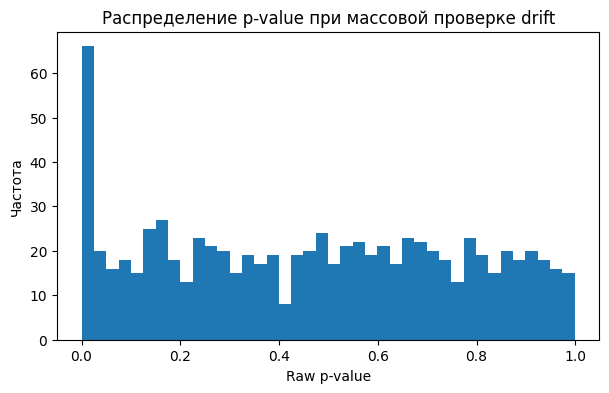

In [ ]:
rng_drift = np.random.default_rng(2040)

n_features = 800
n_train = 250
n_prod = 250
n_shift = 50

train = rng_drift.normal(size=(n_train, n_features))
prod = rng_drift.normal(size=(n_prod, n_features))

shift_features = rng_drift.choice(n_features, size=n_shift, replace=False)
prod[:, shift_features] += rng_drift.normal(loc=0.35, scale=0.08, size=n_shift)

pvals = np.empty(n_features)
effects = np.empty(n_features)

for j in range(n_features):
    test = stats.ttest_ind(train[:, j], prod[:, j], equal_var=False)
    pvals[j] = test.pvalue
    effects[j] = prod[:, j].mean() - train[:, j].mean()

drift_rows = []
for label, mask in [
    ("Без поправки", pvals < 0.05),
    ("Holm", multipletests(pvals, method="holm")[1] < 0.05),
    ("BH", multipletests(pvals, method="fdr_bh")[1] < 0.05),
]:
    discoveries = np.where(mask)[0]
    tp = np.intersect1d(discoveries, shift_features).size
    fp = len(discoveries) - tp
    drift_rows.append({
        "Правило": label,
        "Обнаружений": len(discoveries),
        "Истинных сдвигов": tp,
        "Ложных срабатываний": fp,
        "Precision": np.nan if len(discoveries) == 0 else tp / len(discoveries),
        "Recall": tp / n_shift,
    })

drift_summary = pd.DataFrame(drift_rows)

display(pd.DataFrame({
    "Параметр": ["Всего признаков", "Истинно сдвинутых"],
    "Значение": [n_features, n_shift],
}))
display(drift_summary)

plt.figure(figsize=(7, 4))
plt.hist(pvals, bins=40)
plt.xlabel("Raw p-value")
plt.ylabel("Частота")
plt.title("Распределение p-value при массовой проверке drift")
plt.show()


### Что означает `drift_summary`

- `Обнаружений` — сколько признаков объявлено «сдвинутыми»;
- `Истинных сдвигов` — сколько из них действительно были изменены в симуляции;
- `Ложных срабатываний` — сколько находок ложные;
- `Precision` — доля настоящих находок среди всех найденных;
- `Recall` — доля найденных истинных сигналов.

Здесь особенно хорошо видно различие философий:

- без поправки находится много сигналов, но цена — множество ложных;
- Holm почти не даёт ложных, но теряет часть настоящих сдвигов;
- BH удерживает хороший баланс между precision и recall.

Это и есть практический смысл выбора между FWER и FDR.

# 11. Анализ зависимостей

Связи между признаками нужны в ML не только для описательной статистики.  
Они лежат в основе:

- выбора ковариат;
- variance reduction;
- диагностики trade-off между quality и latency;
- поиска proxy-метрик;
- анализа мультиколлинеарности;
- контроля мониторинговых панелей.

Сразу важное предупреждение: **корреляция не равна причинности**.  
Даже очень большая статистическая связь ещё не доказывает каузальное влияние.

## 11.1. Непрерывные признаки: Pearson, Spearman, Kendall

Пусть для объектов $i=1,\ldots,n$ измерены две величины:
$$
(X_i,Y_i).
$$

### Корреляция Пирсона

Популяционный коэффициент Пирсона:
$$
r_{XY}
=
\frac{
\operatorname{Cov}(X,Y)
}{
\sqrt{\operatorname{Var}(X)\operatorname{Var}(Y)}
}.
$$

Здесь:

- $\operatorname{Cov}(X,Y)$ — ковариация;
- знаменатель нормирует связь на масштабы обеих переменных.

Выборочная оценка:
$$
\hat r_{XY}
=
\frac{
\sum_{i=1}^{n}(x_i-\bar x)(y_i-\bar y)
}{
\sqrt{\sum_{i=1}^{n}(x_i-\bar x)^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar y)^2}
}.
$$

При совместной нормальности и гипотезе
$$
H_0:r_{XY}=0
$$
используют статистику
$$
T=
\hat r_{XY}
\sqrt{\frac{n-2}{1-\hat r_{XY}^2}}.
$$

При $H_0$ она имеет точное распределение
$$
T\sim t_{n-2}.
$$

Вне совместной нормальности эту формулу обычно читают уже как асимптотическую аппроксимацию.

#### Доверительный интервал Фишера

Если
$$
z=\operatorname{arctanh}(\hat r_{XY}),
$$
то примерно
$$
z\approx \mathcal N\!\left(\operatorname{arctanh}(r_{XY}),\frac{1}{n-3}\right).
$$

Отсюда строят интервал для $r_{XY}$ через обратное преобразование $\tanh$.

### Корреляция Спирмена

Спирмен — это корреляция Пирсона, посчитанная по рангам.  
Если связок рангов нет, то
$$
\hat\rho_{XY}
=
1-
\frac{6\sum_{i=1}^{n} d_i^2}{n^3-n},
$$
где
$$
d_i=\operatorname{rank}(x_i)-\operatorname{rank}(y_i).
$$

Спирмен чувствителен к монотонной, но не обязательно линейной связи, и обычно устойчивее к выбросам, чем Pearson.

### Корреляция Кендалла

Кендалл смотрит на согласованные и несогласованные пары наблюдений.  
Если $C$ — число согласованных пар, а $D$ — число несогласованных, то без связок
$$
\hat\tau_{XY}=\frac{C-D}{C+D}.
$$

При $H_0:\tau=0$ и умеренно большом $n$ используется нормальная аппроксимация:
$$
\mathbb E[\hat\tau]=0,
\qquad
\operatorname{Var}(\hat\tau)\approx \frac{2(2n+5)}{9n(n-1)}.
$$

### Как читать три меры вместе

- Pearson лучше всего видит **линейную** связь;
- Spearman — **монотонную** связь;
- Kendall — более «комбинаторную» согласованность порядков.

Если коэффициенты ведут себя похоже, это сильный сигнал устойчивой зависимости. Если Pearson резко отличается от rank-based мер, стоит проверить нелинейность, выбросы или тяжёлые хвосты.


## 11.2. Синтетический набор данных по ML-serving runs

Ниже создаётся таблица запусков и конфигураций модели.  
Она специально устроена так, чтобы показать типичную для индустрии проблему: quality и latency кажутся сильно связанными, потому что обе переменные зависят от размера модели и сложности входа.

In [ ]:
rng_dep = np.random.default_rng(2042)

n_runs = 300
model_size_b = rng_dep.normal(7, 2.2, size=n_runs)          # размер модели в млрд параметров
prompt_complexity = rng_dep.normal(0, 1, size=n_runs)       # абстрактная сложность запроса
cache_hit = np.clip(rng_dep.normal(0.55, 0.08, size=n_runs), 0.2, 0.9)

quality_score = 0.66 + 0.018 * model_size_b + 0.03 * prompt_complexity + rng_dep.normal(0, 0.025, size=n_runs)
latency_ms = 90 + 8 * model_size_b + 10 * prompt_complexity - 25 * cache_hit + rng_dep.normal(0, 6, size=n_runs)
gpu_cost_usd = 0.05 + 0.06 * model_size_b + 0.015 * (1 - cache_hit) + rng_dep.normal(0, 0.04, size=n_runs)
throughput_rps = 1000 / latency_ms + rng_dep.normal(0, 0.2, size=n_runs)

runs = pd.DataFrame({
    "model_size_b": model_size_b,
    "prompt_complexity": prompt_complexity,
    "cache_hit": cache_hit,
    "quality_score": quality_score,
    "latency_ms": latency_ms,
    "gpu_cost_usd": gpu_cost_usd,
    "throughput_rps": throughput_rps,
})

variable_dict = pd.DataFrame({
    "Переменная": runs.columns,
    "Смысл": [
        "размер модели в млрд параметров",
        "сложность пользовательского запроса",
        "cache hit rate",
        "offline / proxy quality score",
        "средняя latency на запуске",
        "стоимость GPU на запрос",
        "throughput запросов в секунду",
    ],
})

display(runs.head())
display(variable_dict)


,model_size_b,prompt_complexity,cache_hit,quality_score,latency_ms,gpu_cost_usd,throughput_rps
0,8.0598,1.2315,0.4952,0.8036,144.9708,0.5052,7.0569
1,5.6359,1.7517,0.5864,0.8317,131.3448,0.3574,7.8341
2,4.4121,-1.0986,0.5442,0.7258,95.3402,0.3821,10.8562
3,9.3673,0.4479,0.5737,0.8257,159.0973,0.6401,6.5691
4,7.1422,0.4731,0.3996,0.7442,143.9332,0.5056,6.8423


,Переменная,Смысл
0,model_size_b,размер модели в млрд параметров
1,prompt_complexity,сложность пользовательского запроса
2,cache_hit,cache hit rate
3,quality_score,offline / proxy quality score
4,latency_ms,средняя latency на запуске
5,gpu_cost_usd,стоимость GPU на запрос
6,throughput_rps,throughput запросов в секунду


### Что означают первые две таблицы

- первая таблица — первые строки набора данных, каждая строка соответствует одному запуску / конфигурации;
- вторая таблица — словарь переменных.

Словарь особенно важен: без содержательной интерпретации корреляционная матрица почти бесполезна.

,quality_score,latency_ms,gpu_cost_usd,cache_hit,throughput_rps
quality_score,1.0000,0.8267,0.6636,0.0949,-0.7955
latency_ms,0.8267,1.0000,0.8041,-0.0482,-0.9626
gpu_cost_usd,0.6636,0.8041,1.0000,-0.0038,-0.7671
cache_hit,0.0949,-0.0482,-0.0038,1.0000,0.0550
throughput_rps,-0.7955,-0.9626,-0.7671,0.0550,1.0000


,quality_score,latency_ms,gpu_cost_usd,cache_hit,throughput_rps
quality_score,1.0000,0.7965,0.6399,0.0960,-0.7860
latency_ms,0.7965,1.0000,0.8014,-0.0409,-0.9833
gpu_cost_usd,0.6399,0.8014,1.0000,-0.0009,-0.7979
cache_hit,0.0960,-0.0409,-0.0009,1.0000,0.0200
throughput_rps,-0.7860,-0.9833,-0.7979,0.0200,1.0000


,quality_score,latency_ms,gpu_cost_usd,cache_hit,throughput_rps
quality_score,1.0000,0.6064,0.4604,0.0645,-0.5966
latency_ms,0.6064,1.0000,0.6047,-0.0294,-0.8934
gpu_cost_usd,0.4604,0.6047,1.0000,-0.0018,-0.5990
cache_hit,0.0645,-0.0294,-0.0018,1.0000,0.0147
throughput_rps,-0.5966,-0.8934,-0.5990,0.0147,1.0000


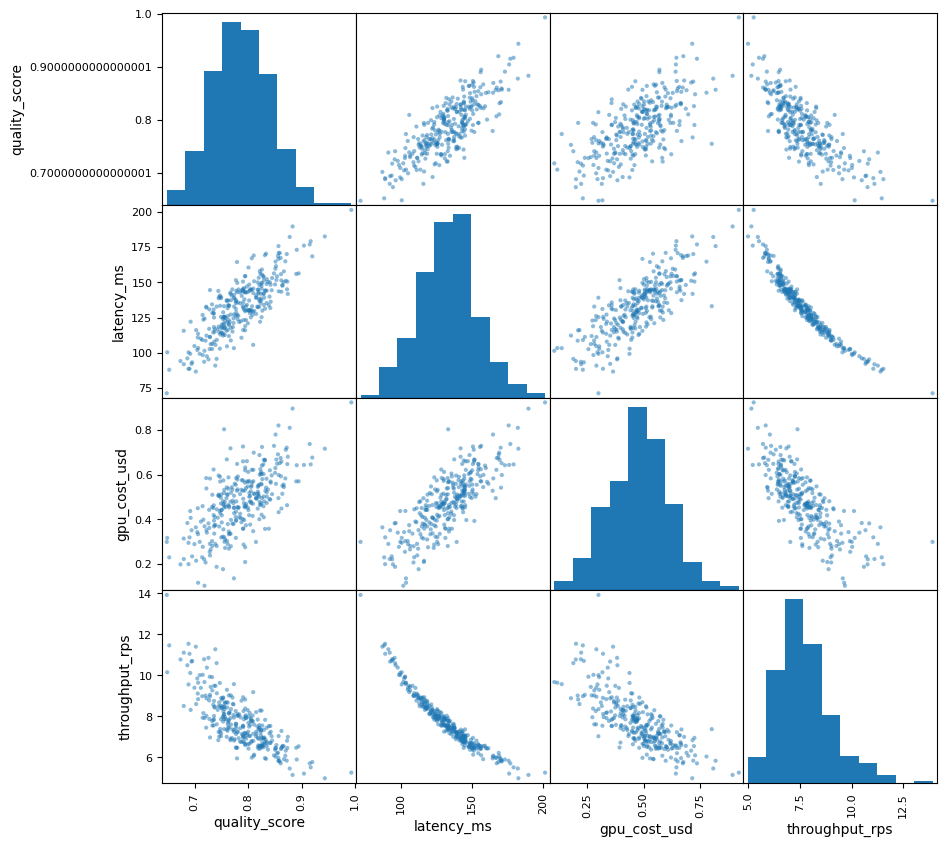

In [ ]:
subset_cols = ["quality_score", "latency_ms", "gpu_cost_usd", "cache_hit", "throughput_rps"]

pearson_corr = runs[subset_cols].corr(method="pearson")
spearman_corr = runs[subset_cols].corr(method="spearman")
kendall_corr = runs[subset_cols].corr(method="kendall")

display(pearson_corr)
display(spearman_corr)
display(kendall_corr)

pd.plotting.scatter_matrix(runs[["quality_score", "latency_ms", "gpu_cost_usd", "throughput_rps"]], figsize=(10, 10))
plt.show()


### Как читать корреляционные матрицы

- каждая ячейка — мера связи между парой признаков;
- положительный знак означает совместный рост;
- отрицательный знак — обратное движение;
- модуль величины показывает силу ассоциации.

Разные меры корреляции отвечают на слегка разные вопросы.

- Pearson лучше всего видит линейную связь.
- Spearman устойчивее к нелинейной монотонности.
- Kendall полезен как более «ранговая» мера согласованности.

Если вывод сохраняется сразу в нескольких матрицах, это усиливает доверие к структуре связи.

## 11.3. Частная и множественная корреляция

Обычная корреляция отвечает на вопрос: связаны ли $X$ и $Y$ вообще?  
Частная корреляция задаёт более тонкий вопрос: связаны ли они **после учёта третьих факторов**?

### Частная корреляция

Если есть три признака $X_1,X_2,X_3$, то
$$
r_{X_1X_2\mid X_3}
=
\frac{
r_{X_1X_2}-r_{X_1X_3}r_{X_2X_3}
}{
\sqrt{(1-r_{X_1X_3}^2)(1-r_{X_2X_3}^2)}
}.
$$

Здесь:

- $r_{X_1X_2}$ — обычная корреляция между $X_1$ и $X_2$;
- $r_{X_1X_3}$ и $r_{X_2X_3}$ — связи с контролирующей переменной $X_3$.

Эта формула показывает, как из общей связи вычитается та её часть, которая может объясняться третьим фактором.

Эквивалентное определение:
$$
r_{XY\mid Z}=\operatorname{Corr}(R_X,R_Y),
$$
где $R_X$ и $R_Y$ — остатки регрессий $X$ и $Y$ на набор контролей $Z$.

Если контролей много и $\Omega$ — корреляционная матрица всех признаков, а
$$
K=\Omega^{-1}
$$
— матрица точности, то
$$
r_{ij\mid M\setminus\{i,j\}}
=
-\frac{K_{ij}}{\sqrt{K_{ii}K_{jj}}}.
$$

### Тест на нулевую частную корреляцию

При многомерной нормальности для проверки
$$
H_0:r_{XY\mid Z}=0
$$
используют статистику
$$
T=
\hat r_{XY\mid Z}
\sqrt{
\frac{n-k-2}{1-\hat r_{XY\mid Z}^2}
}.
$$

В этой модели при $H_0$ она имеет точное распределение
$$
T\sim t_{n-k-2},
$$
где $k$ — число контролируемых переменных.

### Множественная корреляция

Если один признак $Y$ сравнивается сразу с набором ковариат $X_1,\ldots,X_k$, возникает коэффициент множественной корреляции:
$$
R^2=\operatorname{Corr}(Y,\hat Y)^2.
$$

Здесь $\hat Y$ — линейная проекция $Y$ на пространство предикторов.

Для трёх переменных $X_1,X_2,X_3$ формула из лекции имеет вид
$$
R_{X_1;X_2,X_3}
=
\sqrt{
\frac{
r_{X_1X_2}^2+r_{X_1X_3}^2-2r_{X_1X_2}r_{X_1X_3}r_{X_2X_3}
}{
1-r_{X_2X_3}^2
}
}.
$$

В общем матричном виде, если $c$ — вектор корреляций $Y$ с предикторами, то
$$
R^2=c^\top \Omega^{-1}c.
$$

### F-тест для множественной корреляции

Нулевая гипотеза
$$
H_0:R^2=0
$$
эквивалентна отсутствию линейной связи с любым из предикторов. Её проверяют через
$$
F=
\frac{R^2/k}{(1-R^2)/(n-k-1)}
\approx
F_{k,\;n-k-1}.
$$

Для ML-практики это непосредственно связано с линейной регрессией, выбором ковариат, variance reduction и методами вроде CUPED.


In [ ]:
def partial_corr(x, y, Z):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    Z = np.asarray(Z, dtype=float)
    if Z.ndim == 1:
        Z = Z[:, None]
    X = np.column_stack([np.ones(len(Z)), Z])

    beta_x, *_ = np.linalg.lstsq(X, x, rcond=None)
    beta_y, *_ = np.linalg.lstsq(X, y, rcond=None)

    rx = x - X @ beta_x
    ry = y - X @ beta_y

    r, p = stats.pearsonr(rx, ry)
    return r, p

raw_r, raw_p = stats.pearsonr(runs["quality_score"], runs["latency_ms"])
partial_r, partial_p = partial_corr(
    runs["quality_score"],
    runs["latency_ms"],
    runs[["model_size_b", "prompt_complexity", "cache_hit"]],
)

partial_table = pd.DataFrame({
    "Сравнение": [
        "Обычная Corr(quality, latency)",
        "Partial Corr(quality, latency | model_size, prompt_complexity, cache_hit)",
    ],
    "Коэффициент": [raw_r, partial_r],
    "p-value": [raw_p, partial_p],
})

display(partial_table)


,Сравнение,Коэффициент,p-value
0,"Обычная Corr(quality, latency)",0.8267,2.1272e-76
1,"Partial Corr(quality, latency | model_size, prompt_complexity, cache_hit)",0.0435,4.5277e-01


### Как читать `partial_table`

- первая строка показывает «сырой» уровень связи между качеством и latency;
- вторая строка показывает связь после учёта размера модели, сложности запроса и cache hit rate.

Если обычная корреляция большая, а частная резко уменьшается, это означает сильный confounding: переменные выглядели связанными в основном потому, что обе зависели от общего скрытого механизма.

Именно из такой логики затем рождаются variance reduction и CUPED-подходы в A/B-тестах.

## 11.4. Категориальные зависимости и таблицы сопряжённости

Если обе переменные категориальны, центральным объектом становится таблица сопряжённости.  
Пусть $X_1$ принимает $K_1$ значений, а $X_2$ — $K_2$ значений.

### Таблица сопряжённости

Определим
$$
n_{ij}=\#\{X_1=i,\;X_2=j\},
$$

$$
n_{i+}=\sum_{j=1}^{K_2} n_{ij},
\qquad
n_{+j}=\sum_{i=1}^{K_1} n_{ij},
\qquad
n=\sum_{i=1}^{K_1}\sum_{j=1}^{K_2} n_{ij}.
$$

Здесь:

- $n_{ij}$ — число наблюдений в ячейке $(i,j)$;
- $n_{i+}$ — сумма по строке;
- $n_{+j}$ — сумма по столбцу;
- $n$ — общий объём выборки.

### Гипотеза независимости

Если $\pi_{ij}$ — вероятность попасть в ячейку $(i,j)$, то независимость означает
$$
\pi_{ij}=\pi_{i+}\pi_{+j}
\quad
\text{для всех } i,j.
$$

Под $H_0$ ожидаемые частоты равны
$$
E_{ij}=\frac{n_{i+}n_{+j}}{n}.
$$

### Pearson chi-square

Статистика независимости:
$$
\chi^2=
\sum_{i=1}^{K_1}\sum_{j=1}^{K_2}
\frac{(n_{ij}-E_{ij})^2}{E_{ij}}.
$$

При больших выборках
$$
\chi^2\approx \chi^2_{(K_1-1)(K_2-1)}.
$$

Практическая идея проста: если наблюдаемые частоты сильно отличаются от ожидаемых при независимости, статистика становится большой.

### G-test

Likelihood-аналог:
$$
G^2=
2\sum_{i=1}^{K_1}\sum_{j=1}^{K_2}
n_{ij}\log\frac{n_{ij}}{E_{ij}}.
$$

Эта статистика тоже асимптотически имеет $\chi^2$-распределение с теми же степенями свободы.

### Fisher exact test для таблицы 2x2

Для бинарной таблицы с ячейками $a,b,c,d$ и фиксированными суммами по строкам и столбцам вероятность наблюдаемой таблицы равна
$$
\mathbb P(a,b,c,d)
=
\frac{
(a+b)!(c+d)!(a+c)!(b+d)!
}{
a!\,b!\,c!\,d!\,n!
}.
$$

Это и есть основа точного критерия Фишера.  
Он особенно важен при малых выборках или редких событиях, когда асимптотика $\chi^2$-критерия ненадёжна.

### Меры силы связи

Коэффициент Крамера:
$$
V=
\sqrt{
\frac{\chi^2}{n(\min(K_1,K_2)-1)}
}.
$$

Он принимает значения от $0$ до $1$ и измеряет силу связи, а не только факт статистической значимости.

Для бинарной таблицы важна и корреляция Мэтьюса:
$$
MCC=
\frac{ad-bc}{
\sqrt{(a+b)(a+c)(b+d)(c+d)}
}.
$$

Эта мера особенно полезна в ML, потому что симметрично оценивает связь между бинарными переменными и хорошо работает при дисбалансе классов.

### Порядковые категориальные переменные

Если категории упорядочены, можно использовать коэффициент $\gamma$ Гудмана–Краскела:
$$
\gamma=\frac{C-D}{C+D},
$$
где $C$ — число согласованных, а $D$ — число несогласованных пар.  
В отличие от обычного $\chi^2$-теста, $\gamma$ учитывает именно порядок категорий.

### Когда использовать что

- Pearson chi-square — большая выборка и не слишком маленькие ожидаемые частоты;
- Fisher exact — маленькая таблица 2x2 или редкие события;
- Cramer's $V$, MCC, $\gamma$ — для измерения силы связи, а не только факта её наличия.

### Как порождаются таблицы сопряжённости

В зависимости от дизайна исследования одна и та же таблица может иметь разные вероятностные модели.

1. **Пуассоновская схема**: все ячейки случайны и
$$
n_{ij}\sim \operatorname{Poisson}(\mu_{ij}).
$$

2. **Мультиномиальная схема**: общий объём выборки фиксирован, а вся таблица описывается одной мультиномиальной моделью с вероятностями $\pi_{ij}$.

3. **Построчно-мультиномиальная схема**: суммы по строкам фиксированы заранее, и каждая строка имеет собственную мультиномиальную модель.

Эти различия важны концептуально, но критерии независимости типа chi-square и G-test в больших выборках оказываются удивительно устойчивыми и часто приводят к одной и той же практической процедуре.


In [ ]:
# Связь версии модели и появления hallucination на независимом потоке запросов.

hall_table = np.array([
    [3816, 184],   # control: no hallucination / hallucination
    [3954, 146],   # treatment: no hallucination / hallucination
])

chi2_stat, chi2_p, _, _ = stats.chi2_contingency(hall_table, correction=False)
odds_ratio, fisher_p = stats.fisher_exact(hall_table)
cramers_v = np.sqrt(chi2_stat / (hall_table.sum() * (min(hall_table.shape) - 1)))

hall_table_df = pd.DataFrame(
    hall_table,
    index=["Control", "Treatment"],
    columns=["No hallucination", "Hallucination"],
)

hall_summary = pd.DataFrame({
    "Показатель": ["chi-square", "chi-square p-value", "Fisher odds ratio", "Fisher p-value", "Cramer's V"],
    "Значение": [chi2_stat, chi2_p, odds_ratio, fisher_p, cramers_v],
})

display(hall_table_df)
display(hall_summary)


,No hallucination,Hallucination
Control,3816,184
Treatment,3954,146


,Показатель,Значение
0,chi-square,5.5930
1,chi-square p-value,0.0180
2,Fisher odds ratio,0.7658
3,Fisher p-value,0.0183
4,Cramer's V,0.0263


### Что означают показатели в `hall_summary`

- `chi-square` и `chi-square p-value` — проверка независимости строк и столбцов в таблице сопряжённости;
- `Fisher odds ratio` — отношение шансов; значение меньше 1 здесь означает, что hallucination-ошибка в treatment встречается реже;
- `Fisher p-value` — точная проверка для таблицы 2x2;
- `Cramer's V` — нормированная сила связи.

В прикладной работе это помогает отделять два вопроса:

1. есть ли статистически заметная зависимость;
2. насколько эта зависимость велика по масштабу.

## 11.5. Simpson paradox на ML-сегментах

Simpson paradox возникает, когда агрегирование по неоднородным группам переворачивает вывод.

Пусть сегменты обозначены через $s=1,\ldots,S$.  
Внутри каждого сегмента есть свои показатели treatment и control:
$$
p_{T,s},
\qquad
p_{C,s}.
$$

Агрегированные метрики записываются как взвешенные суммы:
$$
\bar p_T=\sum_{s=1}^{S} w_{T,s}p_{T,s},
$$

$$
\bar p_C=\sum_{s=1}^{S} w_{C,s}p_{C,s}.
$$

Здесь:

- $w_{T,s}$ — доля сегмента $s$ внутри treatment;
- $w_{C,s}$ — доля сегмента $s$ внутри control.

Даже если
$$
p_{T,s}>p_{C,s}
\quad
\text{для каждого } s,
$$
вполне возможно, что
$$
\bar p_T<\bar p_C,
$$
если веса $w_{T,s}$ и $w_{C,s}$ сильно различаются.

### Почему это важно для ML-систем

Такое может происходить, если treatment получил более тяжёлый traffic mix:

- больше длинных запросов;
- больше сложных пользователей;
- больше дорогих сценариев инференса;
- больше запросов из регионов с иным latency-профилем.

Тогда даже лучшая по каждому сегменту модель может проиграть агрегированно.

### Главный вывод

Simpson paradox — это напоминание о том, что корректная рандомизация и сопоставимость сегментных весов важны не меньше, чем сами статистические тесты.  
Если mix пользователей в группах различается, агрегированный вывод легко становится вводящим в заблуждение.

In [ ]:
# Два сегмента: short и long queries.
# Treatment лучше внутри каждого сегмента, но получает значительно больше long-запросов.

simpson_counts = {
    "short": {"A": (738, 900), "B": (166, 200)},
    "long": {"A": (58, 100), "B": (470, 800)},
}

rows = []
for segment in ["short", "long"]:
    a_success, a_n = simpson_counts[segment]["A"]
    b_success, b_n = simpson_counts[segment]["B"]
    p_val = proportions_ztest([b_success, a_success], [b_n, a_n])[1]
    rows.append({
        "Срез": segment,
        "Rate A": a_success / a_n,
        "Rate B": b_success / b_n,
        "B - A": b_success / b_n - a_success / a_n,
        "p-value": p_val,
    })

a_success_all = sum(simpson_counts[s]["A"][0] for s in simpson_counts)
a_n_all = sum(simpson_counts[s]["A"][1] for s in simpson_counts)
b_success_all = sum(simpson_counts[s]["B"][0] for s in simpson_counts)
b_n_all = sum(simpson_counts[s]["B"][1] for s in simpson_counts)

rows.append({
    "Срез": "overall",
    "Rate A": a_success_all / a_n_all,
    "Rate B": b_success_all / b_n_all,
    "B - A": b_success_all / b_n_all - a_success_all / a_n_all,
    "p-value": proportions_ztest([b_success_all, a_success_all], [b_n_all, a_n_all])[1],
})

simpson_table = pd.DataFrame(rows)
display(simpson_table)


,Срез,Rate A,Rate B,B - A,p-value
0,short,0.820,0.8300,0.0100,7.3816e-01
1,long,0.580,0.5875,0.0075,8.8582e-01
2,overall,0.796,0.6360,-0.1600,2.1229e-15


### Как читать `simpson_table`

- по строкам `short` и `long` treatment лучше, то есть `B - A > 0`;
- в строке `overall` направление эффекта меняется на противоположное.

Это означает, что агрегат смешивает два режима с разной сложностью и разным распределением трафика.  
В A/B-практике это сигнал к тому, что нужен анализ сегментов, корректировка по ковариатам или более внимательная проверка механики распределения трафика.

# 12. Сложные сценарии A/B-тестов в ML-системах

В первой части был разобран стандартный A/B-тест как базовая каузальная конструкция.  
Теперь добавляются типичные production-усложнения:

1. контроль качества сплита;
2. variance reduction;
3. тяжёлые хвосты у continuous-метрик;
4. несколько метрик одновременно и множественность.

## 12.1. Диагностика качества сплита: SRM

SRM — sample ratio mismatch — это проверка того, согласуются ли фактические размеры групп с теми долями трафика, которые должны были получиться по дизайну эксперимента.

Пусть есть $G$ групп, наблюдаемые размеры
$$
O_1,\ldots,O_G,
$$
и ожидаемые доли
$$
\pi_1,\ldots,\pi_G,
\qquad
\sum_{g=1}^{G}\pi_g=1.
$$

Тогда ожидаемые числа:
$$
E_g=n\pi_g,
\qquad
n=\sum_{g=1}^{G} O_g.
$$

Статистика SRM-теста:
$$
\chi^2_{SRM}
=
\sum_{g=1}^{G}\frac{(O_g-E_g)^2}{E_g}.
$$

При корректном assignment и большом объёме выборки
$$
\chi^2_{SRM}\approx \chi^2_{G-1}.
$$

### Как интерпретировать SRM

Маленький p-value в SRM означает не «интересный treatment-эффект», а структурную проблему эксперимента:

- ошибка маршрутизации;
- различие в eligibility-правилах;
- потеря логов;
- баг в randomization-service;
- селективная фильтрация событий.

Именно поэтому SRM проверяют **до** интерпретации primary-метрики.  
Если сплит сломан, остальные p-values уже не заслуживают доверия.

In [ ]:
def srm_test(counts, expected_proportions=None):
    counts = np.asarray(counts, dtype=float)
    if expected_proportions is None:
        expected_proportions = np.ones(len(counts)) / len(counts)
    expected_proportions = np.asarray(expected_proportions, dtype=float)
    expected_counts = counts.sum() * expected_proportions
    chi2 = ((counts - expected_counts) ** 2 / expected_counts).sum()
    p_value = stats.chi2.sf(chi2, df=len(counts) - 1)
    return chi2, p_value, expected_counts

healthy_counts = np.array([50040, 49860])
broken_counts = np.array([52310, 47190])

healthy_chi2, healthy_p, healthy_exp = srm_test(healthy_counts, [0.5, 0.5])
broken_chi2, broken_p, broken_exp = srm_test(broken_counts, [0.5, 0.5])

srm_table = pd.DataFrame({
    "Эксперимент": ["Корректный сплит", "Подозрительный сплит"],
    "Observed control": [healthy_counts[0], broken_counts[0]],
    "Observed treatment": [healthy_counts[1], broken_counts[1]],
    "Expected per group": [healthy_exp[0], broken_exp[0]],
    "chi-square": [healthy_chi2, broken_chi2],
    "p-value": [healthy_p, broken_p],
})

display(srm_table)


,Эксперимент,Observed control,Observed treatment,Expected per group,chi-square,p-value
0,Корректный сплит,50040,49860,49950.0,0.3243,5.6902e-01
1,Подозрительный сплит,52310,47190,49750.0,263.4613,3.0203e-59


### Что означает `srm_table`

- `Observed control / treatment` — фактические размеры групп;
- `Expected per group` — сколько объектов ожидалось при идеальном сплите;
- `chi-square` и `p-value` — формальная проверка согласия.

Маленький `p-value` на SRM означает **неисправность эксперимента**: ошибка маршрутизации, фильтрации, логирования или экспериментального движка.

## 12.2. CUPED и variance reduction

Пусть есть целевая post-period метрика $Y$ и хорошо связанная с ней pre-period ковариата $X$.  
Тогда строится скорректированная метрика
$$
Y_{cuped}=Y-\theta(X-\bar X).
$$

Здесь:

- $Y$ — post-period outcome;
- $X$ — доэкспериментальная ковариата;
- $\bar X$ — общее среднее ковариаты по тем единицам, на которых строится корректировка;
- $\theta$ — коэффициент коррекции.

Почему вычитается именно $X-\bar X$, а не просто $X$?  
Потому что центрирование делает поправку нулевой «в среднем» и сохраняет treatment-control разность в ожидании при корректной рандомизации.

### Оптимальный коэффициент

Оптимальный в линейном классе коэффициент:
$$
\theta^\star=
\frac{\operatorname{Cov}(Y,X)}{\operatorname{Var}(X)}.
$$

Это точный аналог коэффициента наклона в линейной регрессии $Y$ на $X$.

### Почему именно этот коэффициент минимизирует дисперсию

Рассмотрим
$$
\operatorname{Var}(Y-\theta(X-\bar X)).
$$

Так как вычитание константы $\bar X$ не влияет на дисперсию, имеем
$$
\operatorname{Var}(Y-\theta X)
=
\operatorname{Var}(Y)
-2\theta\operatorname{Cov}(Y,X)
+\theta^2\operatorname{Var}(X).
$$

Это квадратичная функция по $\theta$. Её минимум достигается в точке
$$
\theta^\star=
\frac{\operatorname{Cov}(Y,X)}{\operatorname{Var}(X)}.
$$

### Как меняется дисперсия

Если обозначить обычную линейную корреляцию между $Y$ и $X$ через
$$
\operatorname{Corr}(Y,X),
$$
то при оптимальном $\theta$
$$
\operatorname{Var}(Y_{cuped})
=
\operatorname{Var}(Y)\,\bigl(1-\operatorname{Corr}(Y,X)^2\bigr).
$$

Эта формула чрезвычайно важна: чем сильнее доконтрольная ковариата связана с целевой метрикой, тем сильнее можно уменьшить шум.

### Почему это усиливает эксперимент

Мощность эксперимента зависит от отношения сигнала к шуму.  
CUPED не меняет средний treatment-эффект, но уменьшает дисперсию, а значит:

- делает доверительный интервал уже;
- повышает мощность;
- уменьшает требуемый размер выборки.

С точки зрения линейной модели CUPED — частный случай регрессионной корректировки, близкий к ANCOVA (анализу ковариации).


In [ ]:
# Эксперимент с новой retrieval-моделью.
# Есть pre-period метрика: среднее число полезных действий пользователя за прошлую неделю.

rng_cuped = np.random.default_rng(2044)

n_control = 40000
n_treatment = 39860

pre_control = rng_cuped.normal(3.2, 1.1, size=n_control)
pre_treatment = rng_cuped.normal(3.2, 1.1, size=n_treatment)

post_control = 8.0 + 0.85 * pre_control + rng_cuped.normal(0, 2.2, size=n_control)
post_treatment = 8.0 + 0.85 * pre_treatment + 0.18 + rng_cuped.normal(0, 2.2, size=n_treatment)

pre_all = np.concatenate([pre_control, pre_treatment])
post_all = np.concatenate([post_control, post_treatment])

theta = np.cov(post_all, pre_all, ddof=1)[0, 1] / np.var(pre_all, ddof=1)
pre_mean = pre_all.mean()

cuped_control = post_control - theta * (pre_control - pre_mean)
cuped_treatment = post_treatment - theta * (pre_treatment - pre_mean)

def diff_mean_summary(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    diff = my - mx
    se = np.sqrt(vx / nx + vy / ny)
    df = (vx / nx + vy / ny) ** 2 / ((vx / nx) ** 2 / (nx - 1) + (vy / ny) ** 2 / (ny - 1))
    p = 2 * stats.t.sf(abs(diff / se), df=df)
    ci = stats.t.interval(0.95, df=df, loc=diff, scale=se)
    return diff, se, p, ci

naive_diff, naive_se, naive_p, naive_ci = diff_mean_summary(post_control, post_treatment)
cuped_diff, cuped_se, cuped_p, cuped_ci = diff_mean_summary(cuped_control, cuped_treatment)

variance_reduction = 1 - np.var(np.concatenate([cuped_control, cuped_treatment]), ddof=1) / np.var(post_all, ddof=1)

cuped_table = pd.DataFrame({
    "Подход": ["Naive", "CUPED"],
    "Эффект treatment-control": [naive_diff, cuped_diff],
    "SE": [naive_se, cuped_se],
    "p-value": [naive_p, cuped_p],
    "95% CI low": [naive_ci[0], cuped_ci[0]],
    "95% CI high": [naive_ci[1], cuped_ci[1]],
})

display(pd.DataFrame({
    "Показатель": ["theta", "variance reduction"],
    "Значение": [theta, variance_reduction],
}))
display(cuped_table)


,Показатель,Значение
0,theta,0.8488
1,variance reduction,0.1525


,Подход,Эффект treatment-control,SE,p-value,95% CI low,95% CI high
0,Naive,0.1740,0.0169,7.3900e-25,0.1409,0.2071
1,CUPED,0.1734,0.0156,7.2411e-29,0.1430,0.2039


### Как читать `cuped_table`

- `Naive` — анализ без учёта pre-period информации;
- `CUPED` — анализ после вычитания линейной компоненты, объясняемой ковариатой;
- `Эффект treatment-control` — оценка эффекта почти не меняется;
- `SE` — уменьшается, если ковариата действительно информативна;
- `variance reduction` — доля снижения общей дисперсии.

Содержательный вывод такой: CUPED делает уже существующий сигнал менее шумным.

## 12.3. Тяжёлохвостая continuous-метрика

Многие продуктовые и ML-метрики плохо похожи на учебно-нормальные выборки:

- tokens per conversation;
- cost per resolved session;
- latency per generated answer;
- revenue per assisted checkout;
- время до решения пользовательской задачи.

Такие метрики часто имеют:

- много нулей;
- длинный правый хвост;
- редкие экстремальные выбросы.

### Что именно сравнивается

Если бизнес-цель сформулирована через среднее значение, то параметр интереса остаётся
$$
\tau=\mathbb E[Y_T]-\mathbb E[Y_C].
$$

Даже если распределение очень скошено, именно этот параметр отвечает на вопрос про средний cost, средний revenue или среднюю latency.

### Почему Welch всё ещё имеет смысл

Если дисперсия конечна, то по центральной предельной теореме
$$
\sqrt n\left((\bar Y_T-\bar Y_C)-\tau\right)
\xrightarrow{d}
\mathcal N(0,\sigma_\tau^2).
$$

Это обосновывает использование Welch-теста и нормальных/Student-подобных интервалов для разности средних.

### Зачем рядом нужен bootstrap

В конечной выборке тяжёлые хвосты могут делать асимптотическую аппроксимацию неустойчивой. Поэтому рядом полезно строить bootstrap-распределение
$$
\hat\tau^*=\bar Y_T^*-\bar Y_C^*.
$$

Bootstrap показывает, насколько вывод о среднем эффекте чувствителен к конкретной эмпирической форме хвостов.

### Практический вывод

Для cost-, latency- и revenue-like метрик разумная схема часто выглядит так:

1. основной параметр — разность средних;
2. основной параметрический отчёт — Welch;
3. дополнительная проверка устойчивости — bootstrap;
4. при необходимости — winsorization, trimmed mean или отдельный анализ хвоста.

Такая комбинация позволяет не уходить от бизнес-параметра интереса и одновременно честно работать с неприятной формой распределения.

,Показатель,Значение
0,mean_control,3.2380e-01
1,mean_treatment,2.8088e-01
2,median_control,1.4238e-01
3,median_treatment,1.3426e-01
4,Welch diff,-4.2922e-02
5,Welch p-value,1.2047e-05
6,Welch 95% CI low,-6.2137e-02
7,Welch 95% CI high,-2.3707e-02
8,Bootstrap 95% CI low,-6.2651e-02
9,Bootstrap 95% CI high,-2.4773e-02


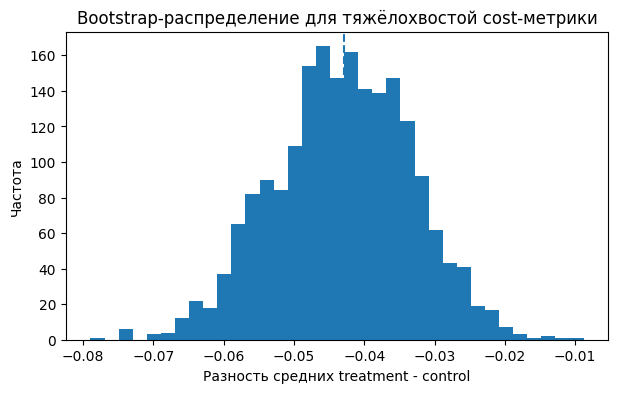

In [ ]:
rng_heavy = np.random.default_rng(2045)

n_control = 6000
n_treatment = 6200

cost_control = rng_heavy.lognormal(mean=np.log(0.28), sigma=1.05, size=n_control)
cost_treatment = rng_heavy.lognormal(mean=np.log(0.26), sigma=0.98, size=n_treatment)

cost_control[rng_heavy.random(n_control) < 0.35] = 0
cost_treatment[rng_heavy.random(n_treatment) < 0.33] = 0

def welch_summary(x, y):
    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    diff = my - mx
    se = np.sqrt(vx / nx + vy / ny)
    df = (vx / nx + vy / ny) ** 2 / ((vx / nx) ** 2 / (nx - 1) + (vy / ny) ** 2 / (ny - 1))
    p = 2 * stats.t.sf(abs(diff / se), df=df)
    ci = stats.t.interval(0.95, df=df, loc=diff, scale=se)
    return diff, se, p, ci

def bootstrap_diff_mean(x, y, n_boot=2000, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    x = np.asarray(x)
    y = np.asarray(y)
    idx_x = rng.integers(0, len(x), size=(n_boot, len(x)))
    idx_y = rng.integers(0, len(y), size=(n_boot, len(y)))
    boot = y[idx_y].mean(axis=1) - x[idx_x].mean(axis=1)
    return np.quantile(boot, [0.025, 0.975]), boot

diff_cost, se_cost, p_cost, ci_cost = welch_summary(cost_control, cost_treatment)
boot_ci_cost, boot_cost = bootstrap_diff_mean(cost_control, cost_treatment, rng=np.random.default_rng(7))

heavy_table = pd.DataFrame({
    "Показатель": [
        "mean_control",
        "mean_treatment",
        "median_control",
        "median_treatment",
        "Welch diff",
        "Welch p-value",
        "Welch 95% CI low",
        "Welch 95% CI high",
        "Bootstrap 95% CI low",
        "Bootstrap 95% CI high",
    ],
    "Значение": [
        cost_control.mean(),
        cost_treatment.mean(),
        np.median(cost_control),
        np.median(cost_treatment),
        diff_cost,
        p_cost,
        ci_cost[0],
        ci_cost[1],
        boot_ci_cost[0],
        boot_ci_cost[1],
    ],
})

display(heavy_table)

plt.figure(figsize=(7, 4))
plt.hist(boot_cost, bins=35)
plt.axvline(diff_cost, linestyle="--")
plt.xlabel("Разность средних treatment - control")
plt.ylabel("Частота")
plt.title("Bootstrap-распределение для тяжёлохвостой cost-метрики")
plt.show()


### Что означает `heavy_table`

- `mean_*` — именно эти величины отвечают за общий cost в продукте;
- `median_*` — помогают понять форму распределения, но не заменяют среднее как business-метрику;
- `Welch diff` и `Welch p-value` — параметрический взгляд на разность средних;
- `Welch 95% CI` — интервал при t-аппроксимации;
- `Bootstrap 95% CI` — интервал, полученный без жёсткой параметрической модели.

Если Welch- и bootstrap-интервалы согласованы по знаку и масштабу, это усиливает уверенность в выводе даже на очень скошенной метрике.

## 12.4. Несколько метрик одновременно: primary, secondary, guardrail

Хороший A/B-отчёт почти никогда не сводится к одной строке.  
Обычно в нём есть:

- **primary metric** — главная заранее выбранная метрика решения;
- **secondary metrics** — дополнительные метрики;
- **guardrail metrics** — защитные метрики, по которым нельзя допустить серьёзного ухудшения;
- сегментные разрезы.

Это сразу возвращает проблему множественности.

### Формальная постановка

Пусть одновременно проверяются гипотезы
$$
H_1,\ldots,H_m
$$
по разным метрикам и сегментам.

Тогда необходимо явно определить, какое именно **семейство гипотез** интерпретируется совместно.  
Без этого невозможно корректно выбрать множественную поправку.

### Типичная промышленная схема

На практике часто применяют такую иерархию:

1. одна заранее объявленная **primary**-метрика анализируется как главный тест;
2. **guardrails** рассматриваются как отдельное семейство защитных гипотез;
3. **secondary** и exploratory-метрики анализируются с Holm- или BH-поправкой.

Если primary-метрик несколько, они сами образуют семейство и тоже требуют множественной коррекции.

### Почему это особенно важно для ML

Новая модель может одновременно влиять на:

- quality;
- latency;
- GPU-cost;
- unsafe rate;
- downstream retention.

Если смотреть на каждую из этих метрик как на независимый случайный эпизод, статистика быстро превращается в машинку по производству ложных открытий.

### Gatekeeping и предрегистрация

**Gatekeeping** — это заранее заданный порядок, в котором интерпретируются семьи гипотез.  
**Предрегистрация** — это фиксация правил анализа до просмотра результатов.

В серьёзных экспериментах полезно заранее фиксировать:

- primary metric;
- правило принятия решения;
- список guardrails;
- семейства гипотез;
- допустимые подгруппы и exploratory-разрезы.

Это защита от post-hoc cherry-picking, то есть от отбора удобных выводов уже после просмотра данных.


In [ ]:
metric_rows = []

def add_binary_metric(name, role, success_control, n_control, success_treatment, n_treatment):
    stat, p = proportions_ztest([success_treatment, success_control], [n_treatment, n_control])
    ci = confint_proportions_2indep(success_treatment, n_treatment, success_control, n_control, method="score")
    p_c = success_control / n_control
    p_t = success_treatment / n_treatment
    metric_rows.append({
        "Метрика": name,
        "Роль": role,
        "Тип": "binary",
        "Control": p_c,
        "Treatment": p_t,
        "Абс. эффект": p_t - p_c,
        "Отн. эффект": p_t / p_c - 1,
        "raw p-value": p,
        "95% CI low": ci[0],
        "95% CI high": ci[1],
    })

def add_continuous_metric(name, role, mean_control, sd_control, n_control, mean_treatment, sd_treatment, n_treatment):
    se = np.sqrt(sd_control ** 2 / n_control + sd_treatment ** 2 / n_treatment)
    df = (sd_control ** 2 / n_control + sd_treatment ** 2 / n_treatment) ** 2 / (
        (sd_control ** 2 / n_control) ** 2 / (n_control - 1) + (sd_treatment ** 2 / n_treatment) ** 2 / (n_treatment - 1)
    )
    diff = mean_treatment - mean_control
    p = 2 * stats.t.sf(abs(diff / se), df=df)
    ci = stats.t.interval(0.95, df=df, loc=diff, scale=se)
    metric_rows.append({
        "Метрика": name,
        "Роль": role,
        "Тип": "continuous",
        "Control": mean_control,
        "Treatment": mean_treatment,
        "Абс. эффект": diff,
        "Отн. эффект": diff / mean_control,
        "raw p-value": p,
        "95% CI low": ci[0],
        "95% CI high": ci[1],
    })

add_binary_metric("Resolved session rate", "primary", 5760, 32000, 6112, 32000)
add_continuous_metric("Avg model calls / session", "secondary", 4.42, 2.10, 12000, 4.58, 2.15, 12100)
add_binary_metric("Latency > 2s rate", "guardrail", 2720, 32000, 3072, 32000)
add_binary_metric("Unsafe reply rate", "guardrail", 198, 32000, 214, 32000)
add_continuous_metric("Tokens / session", "secondary", 820, 450, 12000, 845, 470, 12100)

metrics_table = pd.DataFrame(metric_rows)
metrics_table["Holm adj p"] = multipletests(metrics_table["raw p-value"], method="holm")[1]
metrics_table["BH adj p"] = multipletests(metrics_table["raw p-value"], method="fdr_bh")[1]

display(metrics_table)


,Метрика,Роль,Тип,Control,Treatment,Абс. эффект,Отн. эффект,raw p-value,95% CI low,95% CI high,Holm adj p,BH adj p
0,Resolved session rate,primary,binary,0.1800,0.1910,0.0110,0.0611,3.4411e-04,0.0050,0.0170,6.8823e-04,4.3014e-04
1,Avg model calls / session,secondary,continuous,4.4200,4.5800,0.1600,0.0362,5.1548e-09,0.1063,0.2137,2.5774e-08,2.5774e-08
2,Latency > 2s rate,guardrail,binary,0.0850,0.0960,0.0110,0.1294,1.2356e-06,0.0066,0.0154,4.9425e-06,3.0891e-06
3,Unsafe reply rate,guardrail,binary,0.0062,0.0067,0.0005,0.0808,4.2905e-01,-0.0007,0.0017,4.2905e-01,4.2905e-01
4,Tokens / session,secondary,continuous,820.0000,845.0000,25.0000,0.0305,2.4752e-05,13.3824,36.6176,7.4256e-05,4.1253e-05


### Как читать `metrics_table`

- `Роль` — primary / secondary / guardrail;
- `Тип` — бинарная или непрерывная метрика;
- `Control`, `Treatment` — наблюдаемые уровни метрики;
- `Абс. эффект` — разность treatment минус control;
- `Отн. эффект` — эффект, нормированный на baseline;
- `raw p-value` — результат без поправки;
- `Holm adj p` — FWER-контроль;
- `BH adj p` — FDR-контроль;
- `95% CI` — интервал для эффекта.

Важный принцип интерпретации:

1. сначала проверяется корректность сплита и логирования;
2. затем анализируется primary metric;
3. после этого рассматриваются guardrails;
4. только затем трактуются secondary и сегментные результаты с поправками на множественность.

# 13. Итоговая карта решений

К этому моменту весь материал можно свести в несколько крупных развилок.

## 13.1. Если задач много одновременно

Если одновременно анализируется много p-values, сначала нужно решить, что важнее контролировать:

- **вероятность хотя бы одной ложной находки** — тогда нужны FWER-процедуры;
- **долю ложных находок среди найденных** — тогда уместны FDR-процедуры.

После этого выбирают конкретную поправку:

- Bonferroni / Holm — более строгий контроль;
- BH — более мощный поиск сигналов;
- BY — защита при сложной зависимости.

## 13.2. Если нужно изучить связь между признаками

- непрерывные признаки — Pearson, Spearman, Kendall;
- если есть подозрение на confounding — partial correlation;
- если одна переменная объясняется несколькими — multiple correlation или регрессия;
- категориальные признаки — contingency tables, chi-square, G-test, Fisher exact.

## 13.3. Если это реальный A/B-эксперимент

Прежде чем обсуждать эффект, нужно проверить:

1. корректность сплита (SRM);
2. согласованность единицы рандомизации и единицы анализа;
3. наличие заранее объявленной primary-метрики;
4. семейство secondary и guardrail-гипотез;
5. необходимость variance reduction;
6. устойчивость вывода для тяжёлых хвостов.

Главная идея всей второй части: сложный эксперимент — система статистических решений, которые должны быть согласованы между собой.

In [ ]:
cheatsheet = pd.DataFrame([
    {
        "Ситуация": "Одна средняя величина",
        "Параметр": r"$\mu$",
        "Инструмент": "one-sample t / z",
        "Типичный ML-сюжет": "средняя latency или средний GPU-cost против SLA / target",
    },
    {
        "Ситуация": "Две независимые средние",
        "Параметр": r"$\mu_T-\mu_C$",
        "Инструмент": "Welch t-test",
        "Типичный ML-сюжет": "сравнение training pipeline или continuous-метрики в A/B",
    },
    {
        "Ситуация": "Две связанные средние",
        "Параметр": r"$\mathbb E[D]$",
        "Инструмент": "paired t-test",
        "Типичный ML-сюжет": "две модели на одном наборе запросов",
    },
    {
        "Ситуация": "Одна доля",
        "Параметр": r"$p$",
        "Инструмент": "binomial test + CI",
        "Типичный ML-сюжет": "pass-rate benchmark или unsafe-rate",
    },
    {
        "Ситуация": "Две независимые доли",
        "Параметр": r"$p_T-p_C$",
        "Инструмент": "two-proportion z-test",
        "Типичный ML-сюжет": "standard A/B-test с бинарной primary metric",
    },
    {
        "Ситуация": "Две связанные доли",
        "Параметр": "симметрия discordant пар",
        "Инструмент": "McNemar",
        "Типичный ML-сюжет": "два prompt-template на одном benchmark",
    },
    {
        "Ситуация": "Тяжёлохвостая continuous-метрика",
        "Параметр": "разность средних / медиан",
        "Инструмент": "Welch + bootstrap / Mann–Whitney",
        "Типичный ML-сюжет": "cost per session, tokens per conversation, latency",
    },
    {
        "Ситуация": "Много гипотез сразу",
        "Параметр": "FWER / FDR",
        "Инструмент": "Holm, BH, BY",
        "Типичный ML-сюжет": "много моделей, много сегментов, много признаков",
    },
    {
        "Ситуация": "Связь между непрерывными признаками",
        "Параметр": "Pearson / Spearman / partial corr",
        "Инструмент": "корреляционный анализ",
        "Типичный ML-сюжет": "quality-latency-cost trade-off",
    },
])

display(cheatsheet)


,Ситуация,Параметр,Инструмент,Типичный ML-сюжет
0,Одна средняя величина,$\mu$,one-sample t / z,средняя latency или средний GPU-cost против SLA / target
1,Две независимые средние,$\mu_T-\mu_C$,Welch t-test,сравнение training pipeline или continuous-метрики в A/B
2,Две связанные средние,$\mathbb E[D]$,paired t-test,две модели на одном наборе запросов
3,Одна доля,$p$,binomial test + CI,pass-rate benchmark или unsafe-rate
4,Две независимые доли,$p_T-p_C$,two-proportion z-test,standard A/B-test с бинарной primary metric
5,Две связанные доли,симметрия discordant пар,McNemar,два prompt-template на одном benchmark
6,Тяжёлохвостая continuous-метрика,разность средних / медиан,Welch + bootstrap / Mann–Whitney,"cost per session, tokens per conversation, latency"
7,Много гипотез сразу,FWER / FDR,"Holm, BH, BY","много моделей, много сегментов, много признаков"
8,Связь между непрерывными признаками,Pearson / Spearman / partial corr,корреляционный анализ,quality-latency-cost trade-off


## Финальный чек-лист для студента и аналитика

Перед тем как верить красивому результату, полезно пройти такой мысленный чек-лист.

### Модель и данные

- какая случайная величина фактически наблюдается;
- на какой единице анализа строится вывод;
- независимы ли наблюдения или это парный (paired) / кластерный (clustered) дизайн;
- нет ли тяжёлых хвостов, выбросов, сильной гетероскедастичности.

### Гипотезы и параметр интереса

- какой именно параметр тестируется;
- соответствует ли он продуктовой или ML-задаче;
- это задача превосходства (superiority), неинфериорности (non-inferiority) или эквивалентности (equivalence);
- нужно ли контролировать одно семейство гипотез или несколько.

### Интерпретация

- каков размер эффекта;
- насколько широк доверительный интервал;
- что означает каждая строка в итоговой таблице;
- не спрятан ли за агрегированием парадокс Симпсона;
- нет ли множественности, делающей сырые p-values бессмысленными.

### Экспериментальная дисциплина

- не сломан ли сплит;
- заранее ли были объявлены метрики;
- не происходит ли cherry-picking, то есть выбор только удобных сегментов или подгрупп;
- не используется ли постфактум выбранная альтернативная гипотеза.

Если эти вопросы разобраны честно, статистический вывод обычно становится гораздо надёжнее любой отдельной «значимой» цифры.
